In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = (160, 160)
BATCH_SIZE = 4

BASE_DIR = "../dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "validation")
TEST_DIR = os.path.join(BASE_DIR, "test")

CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
N_CLASSES = len(CLASSES)

print("TensorFlow:", tf.__version__)
print("Train:", os.listdir(TRAIN_DIR))
print("Valid:", os.listdir(VALID_DIR))
print("Test:", os.listdir(TEST_DIR))

TensorFlow: 2.21.0
Train: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Valid: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Test: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [39]:
def contar_imagenes_por_clase(ruta):
    conteo = {}
    for clase in CLASSES:
        carpeta = os.path.join(ruta, clase)
        conteo[clase] = len([
            f for f in os.listdir(carpeta)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
    return conteo

train_count = contar_imagenes_por_clase(TRAIN_DIR)
valid_count = contar_imagenes_por_clase(VALID_DIR)
test_count = contar_imagenes_por_clase(TEST_DIR)

print("Train:", train_count)
print("Valid:", valid_count)
print("Test:", test_count)

Train: {'cardboard': 282, 'glass': 350, 'metal': 287, 'paper': 415, 'plastic': 337, 'trash': 95}
Valid: {'cardboard': 60, 'glass': 75, 'metal': 61, 'paper': 89, 'plastic': 72, 'trash': 20}
Test: {'cardboard': 61, 'glass': 76, 'metal': 62, 'paper': 90, 'plastic': 73, 'trash': 22}


In [40]:
from sklearn.utils.class_weight import compute_class_weight

class_indices = {clase: i for i, clase in enumerate(CLASSES)}

y_train = []
for clase in CLASSES:
    y_train += [class_indices[clase]] * train_count[clase]

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(N_CLASSES),
    y=np.array(y_train)
)

class_weights = {
    i: class_weights_array[i]
    for i in range(N_CLASSES)
}

class_weights

{0: np.float64(1.0437352245862883),
 1: np.float64(0.840952380952381),
 2: np.float64(1.0255516840882695),
 3: np.float64(0.7092369477911646),
 4: np.float64(0.8733926805143423),
 5: np.float64(3.0982456140350876)}

In [41]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=CLASSES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=CLASSES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=CLASSES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 1766 files belonging to 6 classes.
Found 377 files belonging to 6 classes.
Found 384 files belonging to 6 classes.


In [42]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.12),
    layers.RandomContrast(0.10),
], name="data_augmentation")

In [43]:
base_model = keras.applications.MobileNetV3Small(
    input_shape=(160, 160, 3),
    include_top=False,
    weights="imagenet",
    include_preprocessing=True
)

base_model.trainable = False

inputs = keras.Input(shape=(160, 160, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(N_CLASSES, activation="softmax")(x)

model_mobilenet = keras.Model(inputs, outputs)

model_mobilenet.summary()

c:\Users\tomas\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\applications\mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 5, 5, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,013,750 (3.87 MB)

 Trainable params: 74,630 (291.52 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [44]:
model_mobilenet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_fase1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

history_fase1 = model_mobilenet.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=5,
    class_weight=class_weights,
    callbacks=callbacks_fase1
)

Epoch 1/5


c:\Users\tomas\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


442/442 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.5929 - loss: 1.1493 - val_accuracy: 0.7692 - val_loss: 0.6156 - learning_rate: 0.0010
Epoch 2/5
442/442 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7350 - loss: 0.7493 - val_accuracy: 0.7825 - val_loss: 0.5984 - learning_rate: 0.0010
Epoch 3/5
442/442 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.7735 - loss: 0.6503 - val_accuracy: 0.7851 - val_loss: 0.6014 - learning_rate: 0.0010
Epoch 4/5
442/442 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7905 - loss: 0.5549 - val_accuracy: 0.8090 - val_loss: 0.5449 - learning_rate: 0.0010
Epoch 5/5
442/442 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8296 - loss: 0.4829 - val_accuracy: 0.8117 - val_loss: 0.4729 - learning_rate: 0.0010


In [45]:
model_mobilenet.save("modelo_guardado/trashnet_mobilenetv3_small_fase1.keras")
print("Modelo Fase 1 guardado correctamente")

Modelo Fase 1 guardado correctamente


In [46]:
test_loss, test_accuracy = model_mobilenet.evaluate(test_ds)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8047 - loss: 0.5994
Test accuracy: 0.8046875
Test loss: 0.5993908047676086


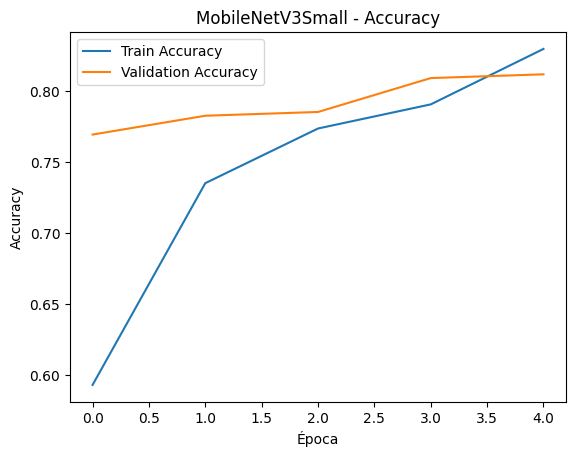

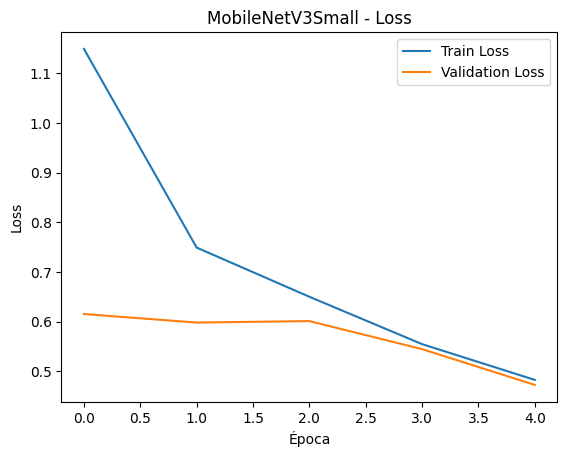

In [47]:
plt.plot(history_fase1.history["accuracy"], label="Train Accuracy")
plt.plot(history_fase1.history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV3Small - Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history_fase1.history["loss"], label="Train Loss")
plt.plot(history_fase1.history["val_loss"], label="Validation Loss")
plt.title("MobileNetV3Small - Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [48]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model_mobilenet.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=N_CLASSES).numpy()
cm

array([[53,  1,  0,  6,  0,  1],
       [ 0, 47, 19,  2,  8,  0],
       [ 0,  2, 59,  0,  1,  0],
       [ 2,  1,  1, 82,  2,  2],
       [ 0,  7,  2,  6, 54,  4],
       [ 2,  0,  0,  5,  1, 14]], dtype=int32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step


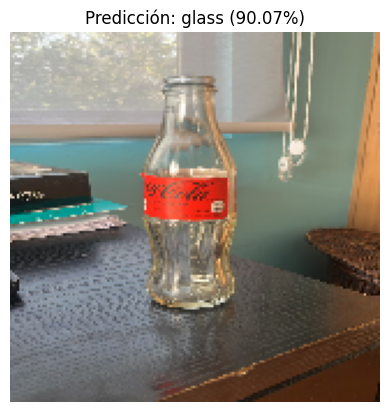

Predicción: glass
Confianza: 90.069885
Probabilidades: {'cardboard': np.float32(0.000104829815), 'glass': np.float32(0.90069884), 'metal': np.float32(0.011267764), 'paper': np.float32(0.014544078), 'plastic': np.float32(0.072725855), 'trash': np.float32(0.0006587787)}


In [51]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Cargar modelo
modelo = tf.keras.models.load_model(
    "modelo_guardado/trashnet_mobilenetv3_small_fase1.keras"
)

# 2. Clases del modelo
clases = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

# 3. Ruta de la imagen a probar
ruta_imagen = r"C:\Users\tomas\OneDrive\Documentos\GitHub\Equipo_dinamita\imagenes_a_test\test 1.jpeg" 

# 4. Cargar y preparar imagen
img = image.load_img(ruta_imagen, target_size=(160, 160))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Normalización MobileNetV3
img_array = tf.keras.applications.mobilenet_v3.preprocess_input(img_array)

# 5. Predicción
prediccion = modelo.predict(img_array)
indice = np.argmax(prediccion)
clase_predicha = clases[indice]
confianza = np.max(prediccion) * 100

# 6. Mostrar resultado
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicción: {clase_predicha} ({confianza:.2f}%)")
plt.show()

print("Predicción:", clase_predicha)
print("Confianza:", confianza)
print("Probabilidades:", dict(zip(clases, prediccion[0])))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step


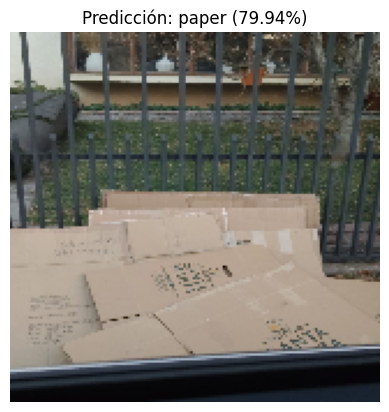

Predicción: paper
Confianza: 79.94247
Probabilidades: {'cardboard': np.float32(0.20001863), 'glass': np.float32(0.00011030953), 'metal': np.float32(0.00037430544), 'paper': np.float32(0.79942465), 'plastic': np.float32(1.6619171e-05), 'trash': np.float32(5.5547047e-05)}


In [53]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Cargar modelo
modelo = tf.keras.models.load_model(
    "modelo_guardado/trashnet_mobilenetv3_small_fase1.keras"
)

# 2. Clases del modelo
clases = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

# 3. Ruta de la imagen a probar
ruta_imagen = r"C:\Users\tomas\OneDrive\Documentos\GitHub\Equipo_dinamita\imagenes_a_test\test 2.jpeg" 

# 4. Cargar y preparar imagen
img = image.load_img(ruta_imagen, target_size=(160, 160))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Normalización MobileNetV3
img_array = tf.keras.applications.mobilenet_v3.preprocess_input(img_array)

# 5. Predicción
prediccion = modelo.predict(img_array)
indice = np.argmax(prediccion)
clase_predicha = clases[indice]
confianza = np.max(prediccion) * 100

# 6. Mostrar resultado
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicción: {clase_predicha} ({confianza:.2f}%)")
plt.show()

print("Predicción:", clase_predicha)
print("Confianza:", confianza)
print("Probabilidades:", dict(zip(clases, prediccion[0])))